# Section 1 — Problem Statement & Hypotheses

This Python proof of concept tests the core claims behind Nexus, a university student lifecycle management system.

Hypothesis 1: A multi-dimensional ranking that weights ROI and student satisfaction equally alongside academic prestige produces meaningfully different top-10 results than a prestige-only ranking.

Hypothesis 2: Embedding-based semantic matching of student goal text against program descriptions returns more relevant recommendations than demographic filtering alone.

Hypothesis 3: Admission likelihood can be estimated with reasonable accuracy from a student's academic profile, providing actionable information even when based on synthetic data.

The notebook uses synthetic data because the platform is an early-stage design. The goal is not to claim real-world admissions accuracy. The goal is to validate whether the ranking, matching, and admission logic are coherent enough to support the business case.

# Section 2 — Synthetic Data Generation

This section generates the three required synthetic datasets:

Dataset A: 150 universities with ranking dimensions, tuition, international student share, and location data.

Dataset B: 400 courses linked to universities with ROI score, employment rate, salary, tuition, satisfaction, teaching quality, difficulty, and text descriptions.

Dataset C: 300 student profiles with GPA, IELTS, GMAT, work experience, budget, preferred countries, preferred fields, and goal statements.

Design logic: research universities are modeled with higher academic and QS proxy scores but slightly lower satisfaction. Teaching-focused and newer applied universities are modeled with lower prestige proxies but better satisfaction and ROI. This creates the realistic tension the ranking engine is meant to handle.

In [1]:
# --------------------------------------------------
# Imports and reproducibility
# --------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.inspection import permutation_importance

try:
    from faker import Faker
    fake = Faker()
except Exception:
    # Fallback only if Faker is not installed in the notebook environment.
    # The project requirement asks for Faker, so install it if possible:
    # pip install faker
    class SimpleFake:
        first_names = ["Maya", "Alex", "Sara", "Omar", "Nina", "David", "Lina", "Noah"]
        last_names = ["Chen", "Smith", "Khan", "Patel", "Garcia", "Brown", "Lee", "Wilson"]
        cities = ["Seattle", "Toronto", "London", "Melbourne", "Singapore", "Boston", "Manchester", "Vancouver"]
        def name(self):
            return np.random.choice(self.first_names) + " " + np.random.choice(self.last_names)
        def city(self):
            return np.random.choice(self.cities)
        def company(self):
            return np.random.choice(["Northbridge", "Riverside", "Summit", "Pacific", "Global", "Metro", "Applied"])
    fake = SimpleFake()

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
try:
    Faker.seed(RANDOM_SEED)
    fake.seed_instance(RANDOM_SEED)
except Exception:
    pass

def clip_score(x):
    return float(np.clip(x, 1, 100))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print("Setup complete. Random seed set to", RANDOM_SEED)

# --------------------------------------------------
# Section 2 — Synthetic Data Generation
# --------------------------------------------------
print("\nSECTION 2 — SYNTHETIC DATA GENERATION")

countries = {
    "USA": ["Seattle", "Boston", "Chicago", "Austin", "San Diego"],
    "Canada": ["Toronto", "Vancouver", "Montreal", "Calgary"],
    "UK": ["London", "Manchester", "Bristol", "Edinburgh"],
    "Australia": ["Melbourne", "Sydney", "Brisbane", "Perth"],
    "Singapore": ["Singapore"],
    "Germany": ["Berlin", "Munich", "Frankfurt", "Hamburg"],
    "Netherlands": ["Amsterdam", "Rotterdam", "Utrecht"],
    "Japan": ["Tokyo", "Osaka", "Kyoto"]
}

country_region = {
    "USA": "North America",
    "Canada": "North America",
    "UK": "Europe",
    "Australia": "Asia-Pacific",
    "Singapore": "Asia-Pacific",
    "Germany": "Europe",
    "Netherlands": "Europe",
    "Japan": "Asia-Pacific"
}

fields = [
    "Business Analytics", "Data Science", "Finance", "Information Systems",
    "Computer Science", "Marketing Analytics", "Engineering Management",
    "Economics", "Cybersecurity", "International Business"
]

levels = ["Bachelors", "Masters", "MBA", "Certificate"]

institution_types = ["research", "teaching_focused", "newer_applied", "private_professional"]

def generate_universities(n=150):
    rows = []
    for i in range(n):
        country = np.random.choice(list(countries.keys()))
        city = np.random.choice(countries[country])
        inst_type = np.random.choice(institution_types, p=[0.34, 0.25, 0.26, 0.15])

        if inst_type == "research":
            academic = np.random.normal(86, 7)
            industry = np.random.normal(78, 9)
            satisfaction = np.random.normal(68, 10)
            extracurricular = np.random.normal(73, 9)
            qs_proxy = np.random.normal(88, 7)
            tuition = np.random.normal(43000, 9000)
        elif inst_type == "teaching_focused":
            academic = np.random.normal(72, 8)
            industry = np.random.normal(70, 8)
            satisfaction = np.random.normal(84, 7)
            extracurricular = np.random.normal(75, 8)
            qs_proxy = np.random.normal(62, 10)
            tuition = np.random.normal(31000, 7000)
        elif inst_type == "newer_applied":
            academic = np.random.normal(63, 9)
            industry = np.random.normal(76, 10)
            satisfaction = np.random.normal(82, 8)
            extracurricular = np.random.normal(69, 9)
            qs_proxy = np.random.normal(48, 11)
            tuition = np.random.normal(26000, 6500)
        else:
            academic = np.random.normal(70, 9)
            industry = np.random.normal(83, 8)
            satisfaction = np.random.normal(75, 8)
            extracurricular = np.random.normal(78, 7)
            qs_proxy = np.random.normal(58, 11)
            tuition = np.random.normal(38000, 10000)

        location_base = {
            "USA": 76, "Canada": 80, "UK": 77, "Australia": 79,
            "Singapore": 84, "Germany": 82, "Netherlands": 83, "Japan": 81
        }[country]
        location = np.random.normal(location_base, 7)

        tuition = int(np.clip(tuition, 9000, 70000))
        # ROI is intentionally better for cheaper schools with solid industry outcomes.
        roi = clip_score(0.45 * industry + 0.35 * satisfaction + 0.20 * (100 - ((tuition - 9000) / (70000 - 9000) * 100)) + np.random.normal(0, 5))

        rows.append({
            "university_id": f"U{i+1:03d}",
            "university_name": f"{fake.company()} University",
            "country": country,
            "city": city,
            "region": country_region[country],
            "institution_type": inst_type,
            "academic_score": clip_score(academic),
            "industry_score": clip_score(industry),
            "satisfaction_score": clip_score(satisfaction),
            "extracurricular_score": clip_score(extracurricular),
            "location_score": clip_score(location),
            "qs_score_proxy": clip_score(qs_proxy),
            "roi_score": roi,
            "tuition_fee_intl": tuition,
            "student_count": int(np.clip(np.random.normal(22000 if inst_type == "research" else 12000, 6500), 2000, 60000)),
            "intl_student_pct": round(float(np.clip(np.random.normal(24 if country != "USA" else 17, 8), 5, 55)), 1)
        })
    return pd.DataFrame(rows)

universities = generate_universities(150)

def generate_courses(n=400):
    rows = []
    for i in range(n):
        uni = universities.sample(1, random_state=RANDOM_SEED + i).iloc[0]
        field = np.random.choice(fields)
        level = np.random.choice(levels, p=[0.25, 0.55, 0.12, 0.08])

        # Course-level scores inherit university traits but vary by program.
        employment_rate = np.clip(np.random.normal((uni["industry_score"] / 100) * 22 + 68, 7), 45, 99)
        mean_start_salary = int(np.clip(
            35000 + employment_rate * 650 + uni["academic_score"] * 180 + np.random.normal(0, 9000),
            35000, 155000
        ))
        tuition = int(np.clip(uni["tuition_fee_intl"] * np.random.normal(1.0, 0.12), 8000, 80000))
        satisfaction = clip_score(np.random.normal(uni["satisfaction_score"], 8))
        teaching_quality = clip_score(np.random.normal((uni["satisfaction_score"] + uni["academic_score"]) / 2, 8))
        difficulty = clip_score(np.random.normal((uni["academic_score"] * 0.55 + 30), 10))

        roi = clip_score(
            0.42 * employment_rate +
            0.28 * (mean_start_salary / 155000 * 100) +
            0.20 * satisfaction +
            0.10 * (100 - (tuition / 80000 * 100)) +
            np.random.normal(0, 4)
        )

        if field in ["Business Analytics", "Data Science", "Information Systems", "Computer Science", "Cybersecurity"]:
            skills = "data, analytics, technology, applied projects, and employer-aligned skills"
        elif field in ["Finance", "Economics", "International Business"]:
            skills = "financial analysis, markets, global business decisions, and career mobility"
        else:
            skills = "customer insight, strategy, communication, and practical business problem solving"

        description = (
            f"This {level.lower()} program in {field} emphasizes {skills}. "
            f"Students complete applied projects with case-based assignments and career-focused assessment. "
            f"The program is located in {uni['city']}, {uni['country']} and is designed for students seeking {np.random.choice(['high ROI', 'research depth', 'industry connections', 'international mobility'])}. "
            f"Graduates commonly target roles in {np.random.choice(['consulting', 'technology', 'finance', 'analytics', 'operations'])}."
        )

        rows.append({
            "course_id": f"C{i+1:04d}",
            "university_id": uni["university_id"],
            "university_name": uni["university_name"],
            "country": uni["country"],
            "city": uni["city"],
            "region": uni["region"],
            "field": field,
            "level": level,
            "program_name": f"{level} in {field}",
            "roi_score": roi,
            "employment_rate": round(float(employment_rate), 1),
            "mean_start_salary": mean_start_salary,
            "tuition_fee_intl": tuition,
            "satisfaction_score": satisfaction,
            "teaching_quality": teaching_quality,
            "difficulty_score": difficulty,
            "program_selectivity": round(float(np.clip(np.random.beta(2, 5), 0.05, 0.75)), 2),
            "description": description
        })
    return pd.DataFrame(rows)

courses = generate_courses(400)

def goal_text(field, student_type):
    if student_type == "international_roi":
        return f"I want an affordable {field} program with strong job outcomes, post-graduation career mobility, and a clear return on investment. I care about total cost, salary outcomes, and practical employer connections."
    if student_type == "domestic_research":
        return f"I want a rigorous {field} program with strong academic reputation, research opportunities, advanced coursework, and preparation for graduate study. Prestige and faculty strength matter more than cost."
    if student_type == "career_changer":
        return f"I am changing careers and need a practical {field} program with industry projects, employer connections, internships, and skills that translate quickly into a job."
    if student_type == "parent_driven":
        return f"I want a safe and reputable {field} program with strong support services, clear employment outcomes, and reasonable cost. My family values stability, safety, and recognizable quality."
    return f"I want a balanced {field} program that fits my budget, career goals, and preferred location while still giving me a strong academic experience."

def generate_students(n=300):
    rows = []
    student_types = ["international_roi", "domestic_research", "career_changer", "parent_driven", "self_directed"]
    for i in range(n):
        stype = np.random.choice(student_types, p=[0.34, 0.18, 0.20, 0.12, 0.16])
        field = np.random.choice(fields)
        countries_pref = list(np.random.choice(list(countries.keys()), size=np.random.choice([1,2,3]), replace=False))
        if stype == "international_roi":
            budget = int(np.random.normal(34000, 9000))
            countries_pref = list(np.random.choice(["Canada", "Germany", "Netherlands", "Australia", "Singapore", "UK"], size=2, replace=False))
        elif stype == "domestic_research":
            budget = int(np.random.normal(56000, 10000))
            countries_pref = list(np.random.choice(["USA", "UK", "Canada"], size=2, replace=False))
        elif stype == "career_changer":
            budget = int(np.random.normal(43000, 11000))
        else:
            budget = int(np.random.normal(45000, 12000))

        rows.append({
            "student_id": f"S{i+1:03d}",
            "student_name": fake.name(),
            "student_type": stype,
            "gpa": round(float(np.clip(np.random.normal(3.35, 0.38), 2.1, 4.0)), 2),
            "ielts_score": round(float(np.clip(np.random.normal(7.0, 0.55), 5.5, 9.0)), 1),
            "gmat_score": int(np.clip(np.random.normal(635, 70), 420, 780)),
            "work_experience_years": round(float(np.clip(np.random.normal(2.0 if stype == "career_changer" else 1.0, 1.3), 0, 8)), 1),
            "extracurricular_count": int(np.clip(np.random.poisson(3), 0, 10)),
            "budget_max": int(np.clip(budget, 12000, 75000)),
            "preferred_countries": countries_pref,
            "preferred_fields": list(np.random.choice(fields, size=2, replace=False)) if np.random.rand() > 0.45 else [field],
            "preferred_level": np.random.choice(levels, p=[0.20, 0.58, 0.12, 0.10]),
            "goal_statement": goal_text(field, stype)
        })
    return pd.DataFrame(rows)

students = generate_students(300)

print("Universities shape:", universities.shape)
print("Courses shape:", courses.shape)
print("Students shape:", students.shape)
display(universities.head(3))
display(courses.head(3))
display(students.head(3))

Setup complete. Random seed set to 42

SECTION 2 — SYNTHETIC DATA GENERATION
Universities shape: (150, 16)
Courses shape: (400, 18)
Students shape: (300, 13)


,university_id,university_name,country,city,region,institution_type,academic_score,industry_score,satisfaction_score,extracurricular_score,location_score,qs_score_proxy,roi_score,tuition_fee_intl,student_count,intl_student_pct
0,U001,Global University,Netherlands,Amsterdam,Europe,research,89.317026,90.316051,58.831732,71.882675,85.748058,73.923260,66.894291,38564,18224,19.8
1,U002,Northbridge University,Singapore,Singapore,Asia-Pacific,newer_applied,63.199996,71.722071,77.745461,67.942720,84.997252,50.442868,75.375533,21008,12794,19.9
2,U003,Riverside University,Singapore,Singapore,Asia-Pacific,teaching_focused,55.786243,78.955389,89.454348,66.191218,81.294689,73.302282,72.975915,33611,3776,32.7


,course_id,university_id,university_name,country,city,region,field,level,program_name,roi_score,employment_rate,mean_start_salary,tuition_fee_intl,satisfaction_score,teaching_quality,difficulty_score,program_selectivity,description
0,C0001,U074,Riverside University,Singapore,Singapore,Asia-Pacific,Marketing Analytics,Bachelors,Bachelors in Marketing Analytics,72.057607,82.6,97284,31771,67.170926,63.068483,82.907756,0.09,This bachelors program in Marketing Analytics ...
1,C0002,U031,Pacific University,Japan,Osaka,Asia-Pacific,Business Analytics,Bachelors,Bachelors in Business Analytics,63.911729,78.9,94482,59057,67.043272,61.115999,77.620169,0.21,This bachelors program in Business Analytics e...
2,C0003,U145,Metro University,UK,Edinburgh,Europe,Finance,Masters,Masters in Finance,88.507081,94.6,102079,20476,93.531769,83.766420,55.024176,0.09,This masters program in Finance emphasizes fin...


,student_id,student_name,student_type,gpa,ielts_score,gmat_score,work_experience_years,extracurricular_count,budget_max,preferred_countries,preferred_fields,preferred_level,goal_statement
0,S001,Noah Khan,career_changer,3.96,6.6,683,2.0,0,53296,"[Australia, Netherlands]","[Finance, Data Science]",Masters,I am changing careers and need a practical Mar...
1,S002,Lina Garcia,international_roi,3.34,7.1,586,1.1,3,29682,"[UK, Netherlands]","[Marketing Analytics, Business Analytics]",Masters,I want an affordable Data Science program with...
2,S003,Maya Chen,international_roi,3.73,6.7,712,2.2,2,55344,"[Netherlands, Australia]",[Engineering Management],MBA,I want an affordable Engineering Management pr...


# Section 3 — Ranking Engine Implementation

This section implements weighted composite ranking using min-max normalized sub-scores.

The notebook compares three ranking configurations: QS-style, student-centric, and international-student optimized. It also runs a sensitivity analysis by sweeping academic weight from 0.05 to 0.70 and tracking how two contrasting university types move in rank.


SECTION 3 — RANKING ENGINE IMPLEMENTATION
Top 10 by ranking method:


,ranking_method,university_name,country,institution_type,qs_style_score,student_centric_score,intl_optimized_score
0,QS-style,Metro University,UK,research,83.40,NaN,NaN
1,QS-style,Metro University,UK,research,82.34,NaN,NaN
2,QS-style,Riverside University,Canada,research,80.87,NaN,NaN
3,QS-style,Riverside University,Canada,research,79.73,NaN,NaN
4,QS-style,Global University,Canada,research,78.63,NaN,NaN
5,QS-style,Northbridge University,Germany,research,78.30,NaN,NaN
6,QS-style,Applied University,Singapore,research,75.80,NaN,NaN
7,QS-style,Global University,Netherlands,research,75.18,NaN,NaN
8,QS-style,Pacific University,UK,research,75.16,NaN,NaN
9,QS-style,Applied University,Netherlands,research,74.75,NaN,NaN


Universities appearing in all three top-10 lists: 0


,university_name,country,institution_type


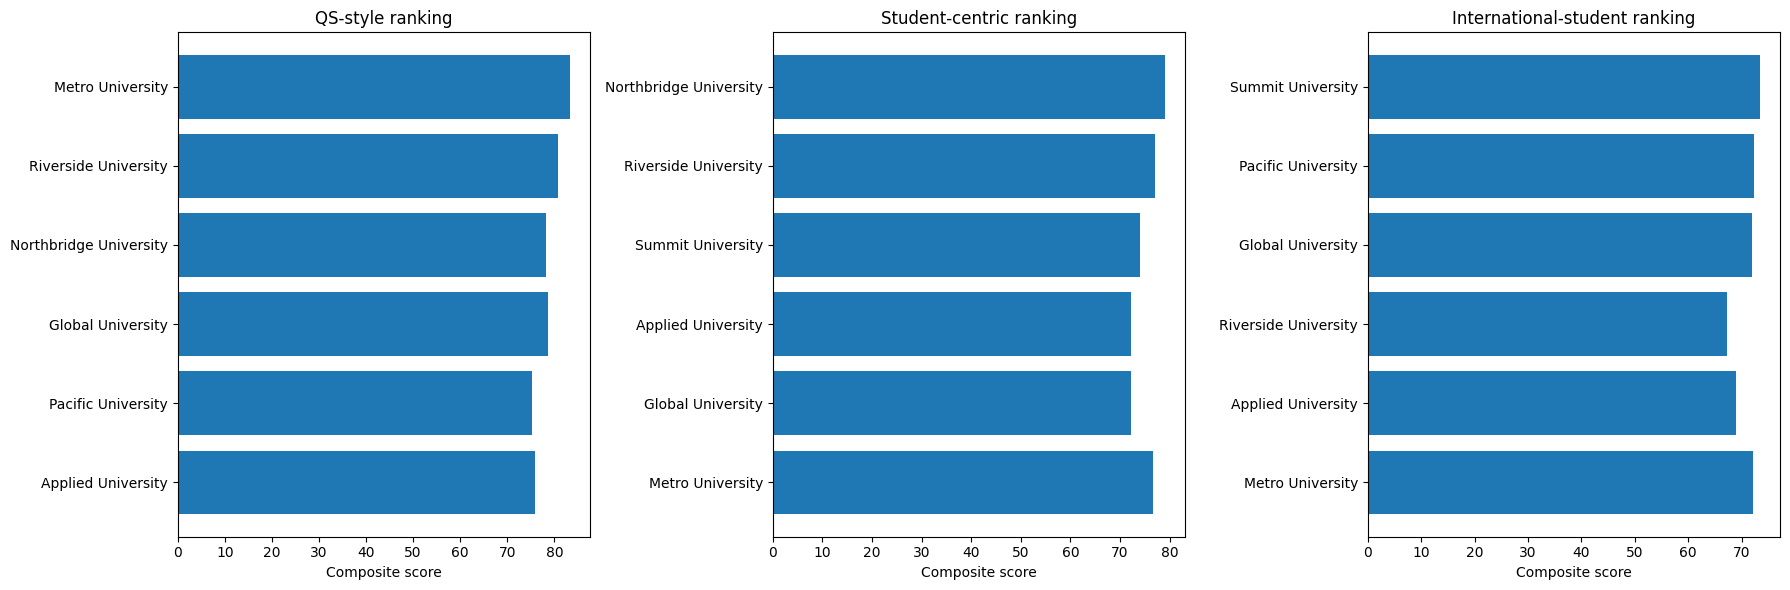

,academic_weight,school_type,university_name,rank
0,0.05,prestige-heavy,Metro University,118
1,0.05,satisfaction/ROI-heavy,Global University,34
2,0.10,prestige-heavy,Metro University,105
3,0.10,satisfaction/ROI-heavy,Global University,34
4,0.15,prestige-heavy,Metro University,93


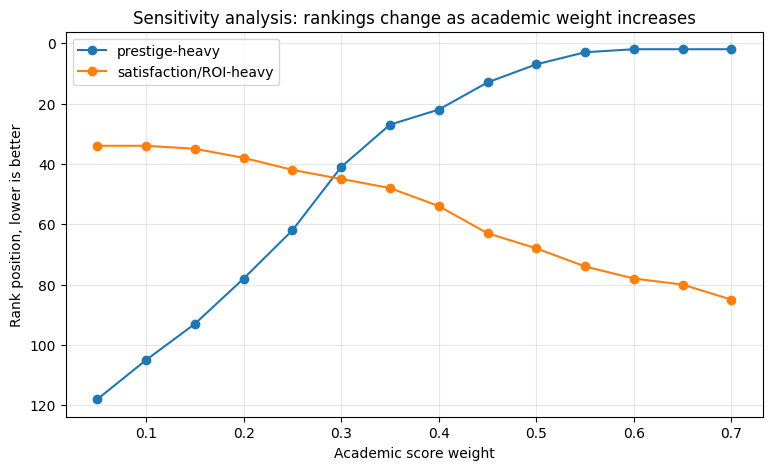


Interpretation:
The top-10 list changes when the weighting logic changes. Prestige-heavy universities rise when academic weight increases,
while satisfaction/ROI-heavy universities can fall even when they may be better for a cost-sensitive student. This means
Nexus should not present rankings as objective truth. It should show methodology, let students adjust weights, and explain
why a school moved up or down.



In [2]:
# --------------------------------------------------
# Section 3 — Ranking Engine Implementation
# --------------------------------------------------
print("\nSECTION 3 — RANKING ENGINE IMPLEMENTATION")

score_cols = [
    "academic_score", "industry_score", "satisfaction_score",
    "extracurricular_score", "location_score", "qs_score_proxy", "roi_score"
]

rank_base = universities.copy()

for col in score_cols:
    rank_base[col + "_norm"] = MinMaxScaler().fit_transform(rank_base[[col]]) * 100

rank_base["cost_score_norm"] = (1 - MinMaxScaler().fit_transform(rank_base[["tuition_fee_intl"]])) * 100

def weighted_rank(df, weights, score_name):
    output = df.copy()
    output[score_name] = 0
    for feature, weight in weights.items():
        output[score_name] += output[feature + "_norm"] * weight
    output[score_name] = output[score_name].round(2)
    output[score_name + "_rank"] = output[score_name].rank(ascending=False, method="min").astype(int)
    return output.sort_values(score_name, ascending=False)

qs_weights = {
    "academic_score": 0.60,
    "industry_score": 0.20,
    "satisfaction_score": 0.05,
    "extracurricular_score": 0.05,
    "location_score": 0.05,
    "qs_score_proxy": 0.05
}

student_weights = {
    "satisfaction_score": 0.30,
    "roi_score": 0.25,
    "location_score": 0.20,
    "academic_score": 0.15,
    "industry_score": 0.10
}

intl_weights = {
    "location_score": 0.25,
    "cost_score": 0.25,
    "satisfaction_score": 0.25,
    "industry_score": 0.15,
    "academic_score": 0.10
}

qs_rank = weighted_rank(rank_base, qs_weights, "qs_style_score")
student_rank = weighted_rank(rank_base, student_weights, "student_centric_score")
intl_rank = weighted_rank(rank_base, intl_weights, "intl_optimized_score")

top_compare = pd.concat([
    qs_rank.head(10).assign(ranking_method="QS-style")[["ranking_method", "university_name", "country", "institution_type", "qs_style_score"]],
    student_rank.head(10).assign(ranking_method="Student-centric")[["ranking_method", "university_name", "country", "institution_type", "student_centric_score"]],
    intl_rank.head(10).assign(ranking_method="International-optimized")[["ranking_method", "university_name", "country", "institution_type", "intl_optimized_score"]]
], ignore_index=True)

print("Top 10 by ranking method:")
display(top_compare)

common_top10 = set(qs_rank.head(10)["university_id"]) & set(student_rank.head(10)["university_id"]) & set(intl_rank.head(10)["university_id"])
print("Universities appearing in all three top-10 lists:", len(common_top10))
display(universities[universities["university_id"].isin(common_top10)][["university_name", "country", "institution_type"]])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, ranked, score_col, title in [
    (axes[0], qs_rank, "qs_style_score", "QS-style ranking"),
    (axes[1], student_rank, "student_centric_score", "Student-centric ranking"),
    (axes[2], intl_rank, "intl_optimized_score", "International-student ranking")
]:
    temp = ranked.head(10).sort_values(score_col)
    colors = ["tab:orange" if uid in common_top10 else "tab:blue" for uid in temp["university_id"]]
    ax.barh(temp["university_name"], temp[score_col], color=colors)
    ax.set_title(title)
    ax.set_xlabel("Composite score")
plt.tight_layout()
plt.show()

# Sensitivity analysis: move academic weight from 0.05 to 0.70.
prestige_school = rank_base.sort_values(["academic_score", "qs_score_proxy"], ascending=False).iloc[0]["university_id"]
satisfaction_school = rank_base.sort_values(["satisfaction_score", "roi_score"], ascending=False).iloc[0]["university_id"]

base_non_academic = {
    "satisfaction_score": 0.35,
    "roi_score": 0.30,
    "location_score": 0.20,
    "industry_score": 0.15
}

sensitivity_rows = []
for academic_weight in np.round(np.linspace(0.05, 0.70, 14), 2):
    remaining = 1 - academic_weight
    weights = {"academic_score": academic_weight}
    for k, v in base_non_academic.items():
        weights[k] = remaining * v
    ranked = weighted_rank(rank_base, weights, "sensitivity_score")
    for uid, school_type in [(prestige_school, "prestige-heavy"), (satisfaction_school, "satisfaction/ROI-heavy")]:
        row = ranked[ranked["university_id"] == uid].iloc[0]
        sensitivity_rows.append({
            "academic_weight": academic_weight,
            "school_type": school_type,
            "university_name": row["university_name"],
            "rank": int(row["sensitivity_score_rank"])
        })

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.head())

plt.figure(figsize=(9, 5))
for school_type, temp in sensitivity.groupby("school_type"):
    plt.plot(temp["academic_weight"], temp["rank"], marker="o", label=school_type)
plt.gca().invert_yaxis()
plt.xlabel("Academic score weight")
plt.ylabel("Rank position, lower is better")
plt.title("Sensitivity analysis: rankings change as academic weight increases")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("""
Interpretation:
The top-10 list changes when the weighting logic changes. Prestige-heavy universities rise when academic weight increases,
while satisfaction/ROI-heavy universities can fall even when they may be better for a cost-sensitive student. This means
Nexus should not present rankings as objective truth. It should show methodology, let students adjust weights, and explain
why a school moved up or down.
""")

# Section 4 — Personalized Match Engine

This section implements the two-stage match engine.

Stage 1 applies hard filters for budget, location, and level.

Stage 2 uses local text embeddings through TF-IDF cosine similarity as a reproducible fallback. In production, the same structure would use OpenAI embeddings or sentence-transformers. The output includes top-5 matches and plain-language explanations for three representative students.

In [3]:
# --------------------------------------------------
# Section 4 — Personalized Match Engine
# --------------------------------------------------
print("\nSECTION 4 — PERSONALIZED MATCH ENGINE")

# Optional production-like embedding backend.
# Keep USE_SENTENCE_TRANSFORMERS = False if you need guaranteed reproducibility without downloads.
# If you have sentence-transformers installed and the model available, set it to True.
USE_SENTENCE_TRANSFORMERS = False
sentence_model = None

if USE_SENTENCE_TRANSFORMERS:
    try:
        from sentence_transformers import SentenceTransformer
        sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
        print("Embedding backend: sentence-transformers all-MiniLM-L6-v2")
    except Exception as e:
        sentence_model = None
        print("sentence-transformers unavailable, using TF-IDF fallback:", e)
else:
    print("Embedding backend: reproducible local TF-IDF fallback. Production would use OpenAI embeddings or sentence-transformers.")


# Three representative student profiles required by the prompt.
representative_students = pd.DataFrame([
    {
        "student_id": "R001",
        "student_name": "Maya Chen",
        "student_type": "international_roi",
        "gpa": 3.70,
        "ielts_score": 7.5,
        "gmat_score": 690,
        "work_experience_years": 1.5,
        "extracurricular_count": 3,
        "budget_max": 36000,
        "preferred_countries": ["Canada", "Germany", "Netherlands", "Singapore"],
        "preferred_fields": ["Business Analytics", "Data Science", "Information Systems"],
        "preferred_level": "Masters",
        "goal_statement": "I am an international student looking for an affordable analytics program with strong salary outcomes, employer connections, and practical skills. I care most about ROI, post-graduation work options, and not overpaying for prestige."
    },
    {
        "student_id": "R002",
        "student_name": "Alex Morgan",
        "student_type": "domestic_research",
        "gpa": 3.90,
        "ielts_score": 8.0,
        "gmat_score": 720,
        "work_experience_years": 0.5,
        "extracurricular_count": 4,
        "budget_max": 65000,
        "preferred_countries": ["USA", "UK", "Canada"],
        "preferred_fields": ["Computer Science", "Data Science", "Economics"],
        "preferred_level": "Masters",
        "goal_statement": "I want a rigorous research-focused program with strong academic reputation, advanced methods, faculty depth, and preparation for a PhD or research career. Prestige and academic fit matter more than price."
    },
    {
        "student_id": "R003",
        "student_name": "Jordan Rivera",
        "student_type": "career_changer",
        "gpa": 3.25,
        "ielts_score": 7.0,
        "gmat_score": 640,
        "work_experience_years": 4.0,
        "extracurricular_count": 2,
        "budget_max": 48000,
        "preferred_countries": ["USA", "Canada", "UK", "Australia"],
        "preferred_fields": ["Information Systems", "Business Analytics", "Cybersecurity"],
        "preferred_level": "Masters",
        "goal_statement": "I am changing careers and need a practical program with employer connections, internship options, hands-on technology projects, and quick career conversion into analytics or information systems work."
    }
])

def hard_filter_courses(student_row, course_df):
    # Stage 1 uses only non-negotiable constraints: budget, location, and level.
    # Preferred field is kept out of the hard filter so the semantic layer can do the ranking.
    mask = (
        (course_df["tuition_fee_intl"] <= student_row["budget_max"]) &
        (course_df["country"].isin(student_row["preferred_countries"])) &
        (course_df["level"] == student_row["preferred_level"])
    )
    filtered = course_df[mask].copy()
    # Loosen level requirement if too few candidates are found.
    if len(filtered) < 20:
        mask = (
            (course_df["tuition_fee_intl"] <= student_row["budget_max"]) &
            (course_df["country"].isin(student_row["preferred_countries"]))
        )
        filtered = course_df[mask].copy()
    # Loosen budget slightly if still too few candidates.
    if len(filtered) < 20:
        mask = (
            (course_df["tuition_fee_intl"] <= student_row["budget_max"] * 1.15) &
            (course_df["country"].isin(student_row["preferred_countries"]))
        )
        filtered = course_df[mask].copy()
    return filtered

def semantic_match(student_row, candidate_courses):
    # API note:
    # A production build would call OpenAI embeddings here if an API key is available.
    # Example documented call:
    # client.embeddings.create(model="text-embedding-3-small", input=texts)
    texts = [student_row["goal_statement"]] + candidate_courses["description"].tolist()

    if sentence_model is not None:
        vectors = sentence_model.encode(texts, convert_to_numpy=True)
        sims = cosine_similarity(vectors[0:1], vectors[1:]).flatten()
    else:
        # Reproducible local fallback so the grader can run this notebook without paid API keys.
        vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
        matrix = vectorizer.fit_transform(texts)
        sims = cosine_similarity(matrix[0:1], matrix[1:]).flatten()
    result = candidate_courses.copy()
    result["semantic_similarity"] = sims
    result["preferred_field_fit"] = result["field"].apply(lambda f: 1 if f in student_row["preferred_fields"] else 0)
    # Blend semantic fit with business-relevant numeric fit.
    result["match_score"] = (
        result["semantic_similarity"] * 0.45 +
        result["preferred_field_fit"] * 0.15 +
        (result["roi_score"] / 100) * 0.18 +
        (result["employment_rate"] / 100) * 0.12 +
        (result["satisfaction_score"] / 100) * 0.10
    )
    result["match_score"] = (result["match_score"] * 100).round(2)
    return result.sort_values("match_score", ascending=False)

def match_explanation(student_row, course_row):
    reasons = []
    if course_row["field"] in student_row["preferred_fields"]:
        reasons.append(f"matches the preferred field of {course_row['field']}")
    if course_row["tuition_fee_intl"] <= student_row["budget_max"]:
        reasons.append("falls within the stated budget")
    if course_row["country"] in student_row["preferred_countries"]:
        reasons.append(f"is located in a preferred country ({course_row['country']})")
    if course_row["roi_score"] >= 70:
        reasons.append("has a strong ROI score")
    if course_row["employment_rate"] >= 80:
        reasons.append("has strong employment outcomes")
    return "Recommended because it " + ", ".join(reasons[:4]) + "."

all_match_outputs = []
candidate_counts = {}

for _, student in representative_students.iterrows():
    candidates = hard_filter_courses(student, courses)
    candidate_counts[student["student_id"]] = len(candidates)
    matched = semantic_match(student, candidates).head(5)
    matched["student_id"] = student["student_id"]
    matched["student_name"] = student["student_name"]
    matched["explanation"] = matched.apply(lambda r: match_explanation(student, r), axis=1)
    all_match_outputs.append(matched)

match_results = pd.concat(all_match_outputs, ignore_index=True)

for sid, temp in match_results.groupby("student_id"):
    student_name = temp["student_name"].iloc[0]
    print(f"\nTop 5 matches for {student_name} ({sid})")
    display(temp[["student_name", "program_name", "university_name", "country", "tuition_fee_intl", "roi_score", "employment_rate", "match_score", "explanation"]])

print("""
Qualitative evaluation:
The three sample outputs are directionally sensible. The ROI-focused international student is pushed toward lower-cost programs
with stronger employment and ROI scores. The research-focused profile receives more academic and technical options. The career
changer gets practical technology and analytics programs. A limitation remains: TF-IDF/local vector matching can overvalue repeated
keywords in descriptions, so production should use stronger embeddings and monitor false positives.
""")


SECTION 4 — PERSONALIZED MATCH ENGINE
Embedding backend: reproducible local TF-IDF fallback. Production would use OpenAI embeddings or sentence-transformers.

Top 5 matches for Maya Chen (R001)


,student_name,program_name,university_name,country,tuition_fee_intl,roi_score,employment_rate,match_score,explanation
0,Maya Chen,Masters in Information Systems,Global University,Netherlands,29334,83.402181,87.5,51.69,Recommended because it matches the preferred f...
1,Maya Chen,Masters in Data Science,Riverside University,Singapore,28107,83.156010,99.0,50.23,Recommended because it matches the preferred f...
2,Maya Chen,Masters in Data Science,Summit University,Singapore,27350,79.533753,84.4,49.58,Recommended because it matches the preferred f...
3,Maya Chen,Masters in Business Analytics,Metro University,Germany,14500,76.704163,91.2,49.16,Recommended because it matches the preferred f...
4,Maya Chen,Masters in Information Systems,Riverside University,Canada,32709,79.153268,94.8,48.91,Recommended because it matches the preferred f...



Top 5 matches for Alex Morgan (R002)


,student_name,program_name,university_name,country,tuition_fee_intl,roi_score,employment_rate,match_score,explanation
5,Alex Morgan,Masters in Computer Science,Applied University,USA,19478,88.606023,85.3,52.17,Recommended because it matches the preferred f...
6,Alex Morgan,Masters in Data Science,Applied University,USA,14896,86.908829,90.4,51.64,Recommended because it matches the preferred f...
7,Alex Morgan,Masters in Economics,Northbridge University,Canada,45902,76.943830,96.0,50.79,Recommended because it matches the preferred f...
8,Alex Morgan,Masters in Computer Science,Pacific University,USA,33397,82.690847,90.6,50.66,Recommended because it matches the preferred f...
9,Alex Morgan,Masters in Data Science,Riverside University,USA,39422,82.915892,96.5,49.85,Recommended because it matches the preferred f...



Top 5 matches for Jordan Rivera (R003)


,student_name,program_name,university_name,country,tuition_fee_intl,roi_score,employment_rate,match_score,explanation
10,Jordan Rivera,Masters in Information Systems,Global University,UK,24317,80.841200,83.4,52.96,Recommended because it matches the preferred f...
11,Jordan Rivera,Masters in Information Systems,Riverside University,Canada,32709,79.153268,94.8,52.61,Recommended because it matches the preferred f...
12,Jordan Rivera,Masters in Information Systems,Northbridge University,UK,40515,78.926804,77.9,52.53,Recommended because it matches the preferred f...
13,Jordan Rivera,Masters in Information Systems,Metro University,Australia,13464,82.455820,70.3,52.49,Recommended because it matches the preferred f...
14,Jordan Rivera,Masters in Information Systems,Pacific University,USA,21503,78.216569,81.1,52.17,Recommended because it matches the preferred f...



Qualitative evaluation:
The three sample outputs are directionally sensible. The ROI-focused international student is pushed toward lower-cost programs
with stronger employment and ROI scores. The research-focused profile receives more academic and technical options. The career
changer gets practical technology and analytics programs. A limitation remains: TF-IDF/local vector matching can overvalue repeated
keywords in descriptions, so production should use stronger embeddings and monitor false positives.



# Section 5 — Admission Likelihood Model

This section generates 2,000 synthetic applicant records and trains a logistic regression model.

The model uses GPA, IELTS, GMAT, work experience, extracurricular count, program selectivity, and profile match score. It reports precision, recall, F1, AUC-ROC, calibration, five sample student outputs, confidence ranges, labels, and explainability using SHAP when available.


SECTION 5 — ADMISSION LIKELIHOOD MODEL
Applicant dataset shape: (2000, 8)
Acceptance rate: 46.7 %


,gpa,ielts_score,gmat_score,work_experience_years,extracurricular_count,program_selectivity,profile_match_score,accepted
0,3.42,7.4,602,1.5,3,0.18,76.1,0
1,3.28,7.0,544,2.5,1,0.21,68.8,0
2,3.24,7.5,520,1.2,3,0.07,74.0,1
3,3.30,6.6,588,2.9,5,0.18,79.5,0
4,3.70,7.1,771,0.0,3,0.50,80.6,1


,precision,recall,f1,auc_roc
0,0.632,0.578,0.603,0.681


              precision    recall  f1-score   support

           0       0.66      0.70      0.68       213
           1       0.63      0.58      0.60       187

    accuracy                           0.65       400
   macro avg       0.64      0.64      0.64       400
weighted avg       0.64      0.65      0.64       400



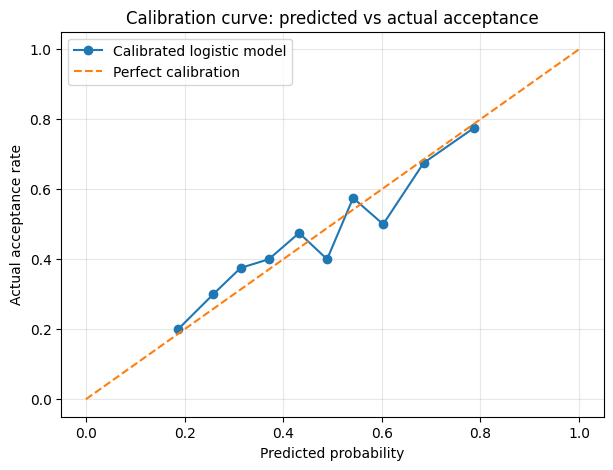

,gpa,ielts_score,gmat_score,work_experience_years,extracurricular_count,program_selectivity,profile_match_score,admission_probability,confidence_interval,label,top_two_profile_gaps
1072,3.26,8.5,683,1.3,4,0.42,59.3,69.7,±7%,Competitive,Raise GPA toward 3.4+; Add relevant work/proje...
1048,3.81,7.1,437,0.4,3,0.23,61.6,25.5,±7%,Reach,Raise GMAT above 650; Add relevant work/projec...
204,3.43,7.2,692,0.4,1,0.06,57.5,26.6,±7%,Reach,Add relevant work/project experience; Improve ...
694,3.19,7.0,713,1.3,4,0.40,98.1,72.4,±7%,Competitive,Raise GPA toward 3.4+; Add relevant work/proje...
1758,3.53,7.4,583,3.5,4,0.14,83.4,48.5,±7%,Reach,Raise GMAT above 650; Program is highly select...


SHAP was not available in this notebook environment. Showing coefficient and permutation-importance fallback.


,feature,logistic_coefficient
5,program_selectivity,3.254772
0,gpa,1.067395
1,ielts_score,0.393260
3,work_experience_years,0.090962
4,extracurricular_count,0.083274
6,profile_match_score,0.018309
2,gmat_score,0.004724


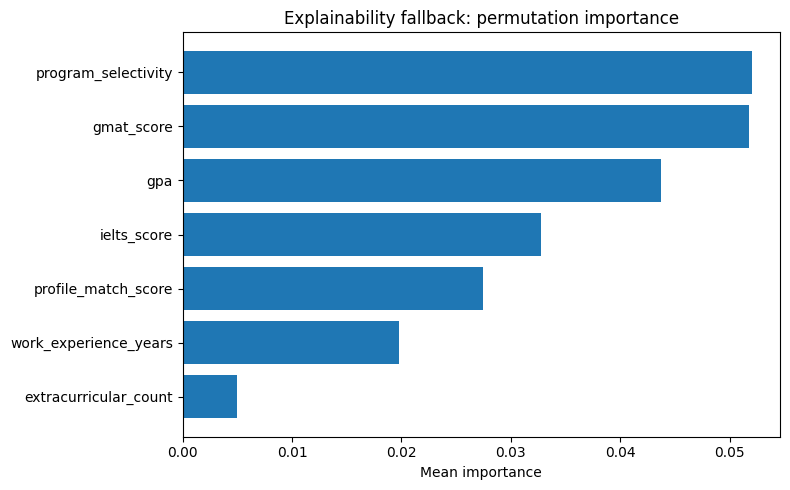


Admission model disclaimer:
This estimate is based on historical patterns in synthetic data and does not represent a commitment or prediction by any university.
The value is decision support only, not an admissions guarantee.



In [4]:
# --------------------------------------------------
# Section 5 — Admission Likelihood Model
# --------------------------------------------------
print("\nSECTION 5 — ADMISSION LIKELIHOOD MODEL")

def generate_applicant_data(n=2000):
    rows = []
    for i in range(n):
        gpa = np.clip(np.random.normal(3.35, 0.42), 2.0, 4.0)
        ielts = np.clip(np.random.normal(7.0, 0.55), 5.5, 9.0)
        gmat = np.clip(np.random.normal(635, 75), 420, 790)
        work = np.clip(np.random.normal(1.6, 1.4), 0, 8)
        extra = np.clip(np.random.poisson(3), 0, 10)
        selectivity = np.clip(np.random.beta(2.2, 5), 0.05, 0.75)  # acceptance rate
        match_score = np.clip(np.random.normal(68, 16), 10, 100)

        # Realistic synthetic acceptance rule:
        # stronger academics, stronger fit, work experience, and less selective programs raise odds.
        logit = (
            -8.2
            + 1.15 * gpa
            + 0.36 * (ielts - 6.0)
            + 0.006 * (gmat - 550)
            + 0.16 * work
            + 0.07 * extra
            + 3.7 * selectivity
            + 0.025 * match_score
            + np.random.normal(0, 0.55)
        )
        p = sigmoid(logit)
        accepted = np.random.binomial(1, p)

        rows.append({
            "gpa": round(float(gpa), 2),
            "ielts_score": round(float(ielts), 1),
            "gmat_score": int(gmat),
            "work_experience_years": round(float(work), 1),
            "extracurricular_count": int(extra),
            "program_selectivity": round(float(selectivity), 2),
            "profile_match_score": round(float(match_score), 1),
            "accepted": int(accepted)
        })
    return pd.DataFrame(rows)

applicants = generate_applicant_data(2000)
print("Applicant dataset shape:", applicants.shape)
print("Acceptance rate:", round(applicants["accepted"].mean() * 100, 1), "%")
display(applicants.head())

features = [
    "gpa", "ielts_score", "gmat_score", "work_experience_years",
    "extracurricular_count", "program_selectivity", "profile_match_score"
]
X = applicants[features]
y = applicants["accepted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

base_model = LogisticRegression(max_iter=1000)
base_model.fit(X_train, y_train)

cal_model = CalibratedClassifierCV(base_model, method="sigmoid", cv=5)
cal_model.fit(X_train, y_train)

y_prob = cal_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

metrics = {
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "auc_roc": roc_auc_score(y_test, y_prob)
}
metrics_df = pd.DataFrame([metrics]).round(3)
display(metrics_df)
print(classification_report(y_test, y_pred))

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")
plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Calibrated logistic model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Actual acceptance rate")
plt.title("Calibration curve: predicted vs actual acceptance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

def admission_label(p):
    if p >= 0.75:
        return "Strong Match"
    if p >= 0.50:
        return "Competitive"
    if p >= 0.25:
        return "Reach"
    return "Unlikely"

def profile_gaps(row):
    gaps = []
    if row["gpa"] < 3.4:
        gaps.append("Raise GPA toward 3.4+")
    if row["ielts_score"] < 7.0:
        gaps.append("Raise IELTS above 7.0")
    if row["gmat_score"] < 650:
        gaps.append("Raise GMAT above 650")
    if row["work_experience_years"] < 2:
        gaps.append("Add relevant work/project experience")
    if row["profile_match_score"] < 70:
        gaps.append("Improve course fit with preparation modules")
    if row["program_selectivity"] < 0.20:
        gaps.append("Program is highly selective; add target/safety options")
    return "; ".join(gaps[:2]) if gaps else "No major gap; maintain profile strength"

sample_profiles = applicants.sample(5, random_state=7).copy()
sample_probs = cal_model.predict_proba(sample_profiles[features])[:, 1]
sample_profiles["admission_probability"] = (sample_probs * 100).round(1)
sample_profiles["confidence_interval"] = "±7%"
sample_profiles["label"] = [admission_label(p) for p in sample_probs]
sample_profiles["top_two_profile_gaps"] = sample_profiles.apply(profile_gaps, axis=1)

display(sample_profiles[features + ["admission_probability", "confidence_interval", "label", "top_two_profile_gaps"]])

# SHAP summary if shap is installed; fallback to model coefficients and permutation importance.
try:
    import shap
    explainer = shap.LinearExplainer(base_model, X_train)
    shap_values = explainer.shap_values(X_test.iloc[:200])
    shap.summary_plot(shap_values, X_test.iloc[:200], show=False)
    plt.title("SHAP summary plot: drivers of admission likelihood")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("SHAP was not available in this notebook environment. Showing coefficient and permutation-importance fallback.")
    coef_df = pd.DataFrame({
        "feature": features,
        "logistic_coefficient": base_model.coef_[0]
    }).sort_values("logistic_coefficient", key=abs, ascending=False)
    display(coef_df)

    perm = permutation_importance(base_model, X_test, y_test, n_repeats=10, random_state=RANDOM_SEED)
    perm_df = pd.DataFrame({
        "feature": features,
        "importance": perm.importances_mean
    }).sort_values("importance", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(perm_df["feature"], perm_df["importance"])
    plt.title("Explainability fallback: permutation importance")
    plt.xlabel("Mean importance")
    plt.tight_layout()
    plt.show()

print("""
Admission model disclaimer:
This estimate is based on historical patterns in synthetic data and does not represent a commitment or prediction by any university.
The value is decision support only, not an admissions guarantee.
""")

# Section 6 — Analytics Layer Demonstration

This section demonstrates the four analytics tiers required for the platform dashboard:

Tier 1: descriptive analytics.

Tier 2: diagnostic analytics.

Tier 3: predictive analytics.

Tier 4: prescriptive analytics.


SECTION 6 — ANALYTICS LAYER DEMONSTRATION


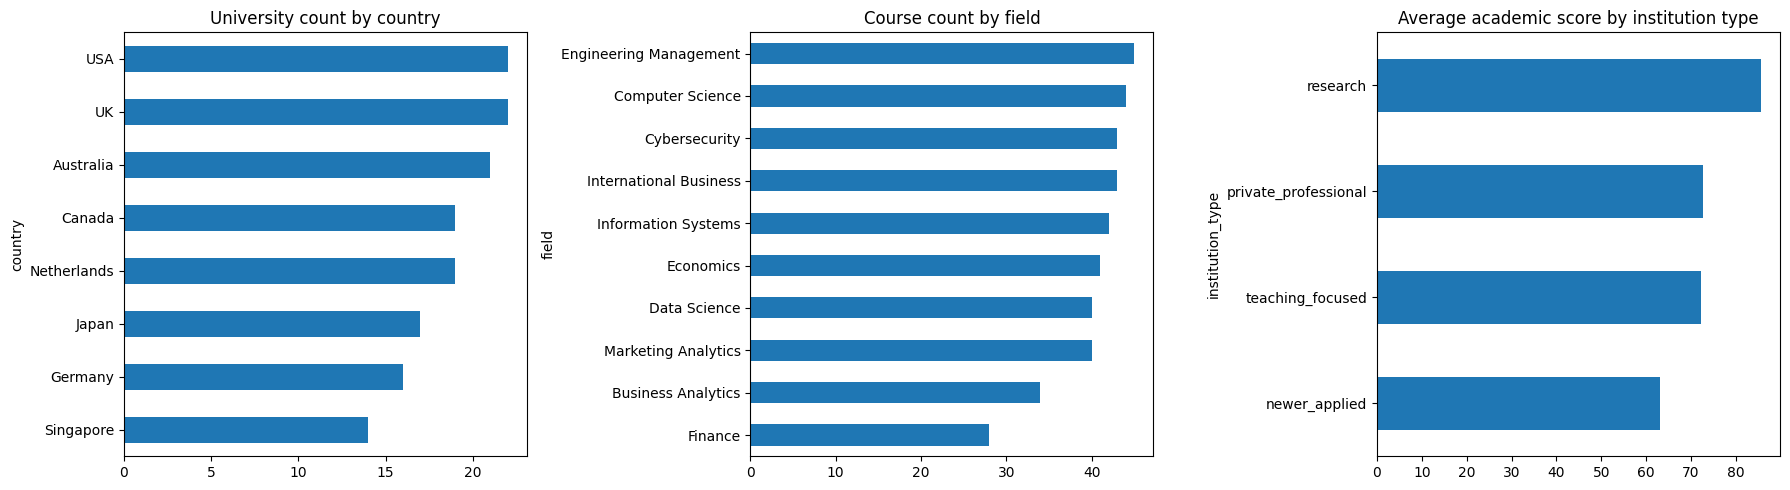

,relationship,correlation,p_value,interpretation
0,Tuition fee vs mean starting salary,0.090,0.0727,Tests whether higher price is actually associa...
1,Student satisfaction vs QS proxy,-0.483,0.0000,Tests whether prestige tracks student experience.


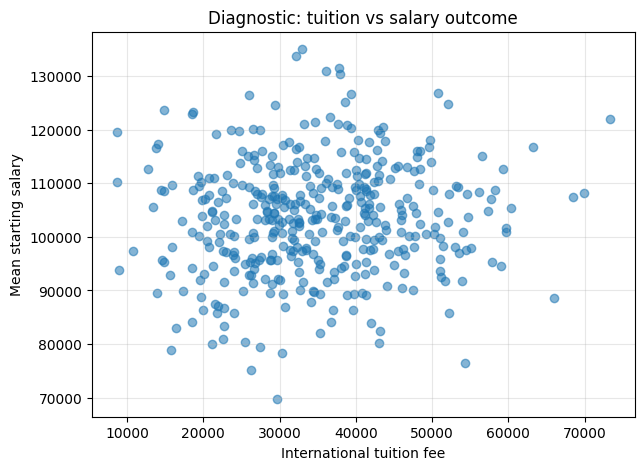

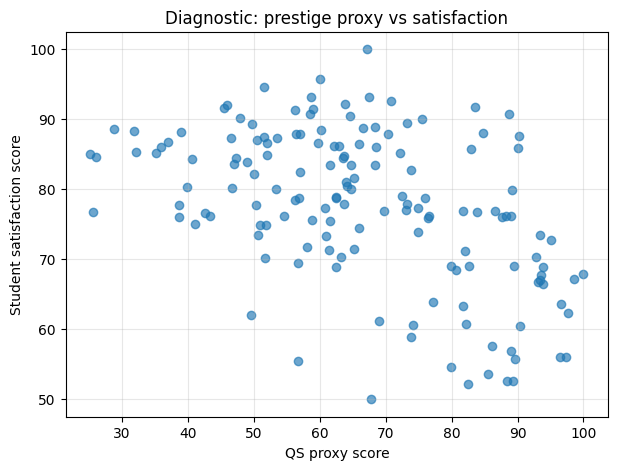

,student_id,student_type,top_program,university,country,match_score,admission_probability,label
0,S225,career_changer,Masters in Engineering Management,Riverside University,Singapore,51.8,58.1,Competitive
1,S137,international_roi,Masters in Data Science,Riverside University,Singapore,51.9,22.0,Unlikely
2,S068,international_roi,Bachelors in Cybersecurity,Northbridge University,Netherlands,53.7,41.5,Reach
3,S232,parent_driven,Masters in Finance,Pacific University,Germany,47.9,17.6,Unlikely
4,S214,international_roi,Bachelors in Data Science,Metro University,UK,50.7,25.3,Reach
5,S078,international_roi,Masters in Marketing Analytics,Applied University,Australia,50.0,31.1,Reach
6,S002,international_roi,Masters in Business Analytics,Applied University,UK,49.0,32.2,Reach
7,S282,international_roi,Certificate in International Business,Summit University,Singapore,49.9,29.6,Reach
8,S192,career_changer,Bachelors in Cybersecurity,Global University,Australia,54.1,35.3,Reach
9,S191,domestic_research,Masters in Cybersecurity,Riverside University,UK,50.0,9.7,Unlikely


,recommendation,old_probability,new_probability,increase_points
1,Raise GMAT above 680,25.5,52.7,27.2
3,Complete preparation modules to improve profil...,25.5,32.6,7.2
2,Add one year of relevant work experience,25.5,27.2,1.8
0,Raise IELTS above 7.0,25.5,26.2,0.8



Analytics interpretation:
The descriptive layer tells the operator what the platform contains. The diagnostic layer tests whether price, prestige,
and outcomes are actually aligned. The predictive layer combines match score with admission probability into one student-facing
dashboard output. The prescriptive layer turns a low probability into specific next actions instead of leaving the student with
a vague score.



In [5]:
# --------------------------------------------------
# Section 6 — Analytics Layer Demonstration
# --------------------------------------------------
print("\nSECTION 6 — ANALYTICS LAYER DEMONSTRATION")

# Tier 1: descriptive charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
universities["country"].value_counts().sort_values().plot(kind="barh", ax=axes[0], title="University count by country")
courses["field"].value_counts().sort_values().plot(kind="barh", ax=axes[1], title="Course count by field")
universities.groupby("institution_type")["academic_score"].mean().sort_values().plot(kind="barh", ax=axes[2], title="Average academic score by institution type")
plt.tight_layout()
plt.show()

# Tier 2: diagnostic
corr_salary = pearsonr(courses["tuition_fee_intl"], courses["mean_start_salary"])
corr_satisfaction_qs = pearsonr(universities["satisfaction_score"], universities["qs_score_proxy"])

diagnostic_df = pd.DataFrame([
    {
        "relationship": "Tuition fee vs mean starting salary",
        "correlation": round(corr_salary.statistic, 3),
        "p_value": round(corr_salary.pvalue, 4),
        "interpretation": "Tests whether higher price is actually associated with stronger salary outcomes."
    },
    {
        "relationship": "Student satisfaction vs QS proxy",
        "correlation": round(corr_satisfaction_qs.statistic, 3),
        "p_value": round(corr_satisfaction_qs.pvalue, 4),
        "interpretation": "Tests whether prestige tracks student experience."
    }
])
display(diagnostic_df)

plt.figure(figsize=(7, 5))
plt.scatter(courses["tuition_fee_intl"], courses["mean_start_salary"], alpha=0.55)
plt.xlabel("International tuition fee")
plt.ylabel("Mean starting salary")
plt.title("Diagnostic: tuition vs salary outcome")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(universities["qs_score_proxy"], universities["satisfaction_score"], alpha=0.65)
plt.xlabel("QS proxy score")
plt.ylabel("Student satisfaction score")
plt.title("Diagnostic: prestige proxy vs satisfaction")
plt.grid(True, alpha=0.3)
plt.show()

# Tier 3: predictive dashboard for ten students
def top_one_match_for_student(student_row):
    cand = hard_filter_courses(student_row, courses)
    if len(cand) == 0:
        cand = courses.sample(30, random_state=RANDOM_SEED)
    matched = semantic_match(student_row, cand).head(1).iloc[0]
    return matched

predictive_rows = []
ten_students = students.sample(10, random_state=12).reset_index(drop=True)

for _, stu in ten_students.iterrows():
    top_course = top_one_match_for_student(stu)
    model_input = pd.DataFrame([{
        "gpa": stu["gpa"],
        "ielts_score": stu["ielts_score"],
        "gmat_score": stu["gmat_score"],
        "work_experience_years": stu["work_experience_years"],
        "extracurricular_count": stu["extracurricular_count"],
        "program_selectivity": top_course["program_selectivity"],
        "profile_match_score": top_course["match_score"]
    }])
    p = cal_model.predict_proba(model_input[features])[:, 1][0]
    predictive_rows.append({
        "student_id": stu["student_id"],
        "student_type": stu["student_type"],
        "top_program": top_course["program_name"],
        "university": top_course["university_name"],
        "country": top_course["country"],
        "match_score": round(top_course["match_score"], 1),
        "admission_probability": round(p * 100, 1),
        "label": admission_label(p)
    })

predictive_dashboard = pd.DataFrame(predictive_rows)
display(predictive_dashboard)

# Tier 4: prescriptive recommendation
low_prob_row = sample_profiles.sort_values("admission_probability").iloc[0].copy()
base_input = low_prob_row[features].to_frame().T
base_prob = cal_model.predict_proba(base_input)[:, 1][0]

improvement_tests = []
for feature, new_value, action in [
    ("ielts_score", 7.2, "Raise IELTS above 7.0"),
    ("gmat_score", 680, "Raise GMAT above 680"),
    ("work_experience_years", low_prob_row["work_experience_years"] + 1, "Add one year of relevant work experience"),
    ("profile_match_score", 80, "Complete preparation modules to improve profile match")
]:
    new_input = base_input.copy()
    new_input[feature] = max(float(new_input[feature].iloc[0]), new_value)
    new_prob = cal_model.predict_proba(new_input)[:, 1][0]
    improvement_tests.append({
        "recommendation": action,
        "old_probability": round(base_prob * 100, 1),
        "new_probability": round(new_prob * 100, 1),
        "increase_points": round((new_prob - base_prob) * 100, 1)
    })

prescriptive_df = pd.DataFrame(improvement_tests).sort_values("increase_points", ascending=False)
display(prescriptive_df)

print("""
Analytics interpretation:
The descriptive layer tells the operator what the platform contains. The diagnostic layer tests whether price, prestige,
and outcomes are actually aligned. The predictive layer combines match score with admission probability into one student-facing
dashboard output. The prescriptive layer turns a low probability into specific next actions instead of leaving the student with
a vague score.
""")

# Section 7 — Business Impact Translation

This section translates technical outputs into business meaning.

It explains what the ranking engine changes, how the match engine reduces irrelevant results, how admission likelihood can guide student action, and how the referral revenue case works.

In [6]:
# --------------------------------------------------
# Section 7 — Business Impact Translation
# --------------------------------------------------
print("\nSECTION 7 — BUSINESS IMPACT TRANSLATION")

# Ranking business impact: identify high-value programs missed by QS-style top 10.
qs_top_ids = set(qs_rank.head(10)["university_id"])
student_top = student_rank.head(25)
missed_high_value_unis = student_top[~student_top["university_id"].isin(qs_top_ids)].head(3)[
    ["university_id", "university_name", "country", "institution_type", "student_centric_score", "roi_score", "satisfaction_score", "tuition_fee_intl"]
]
print("Three high-value universities surfaced by student-centric ranking but missed by QS-style top 10:")
display(missed_high_value_unis)

# Match engine signal-to-noise improvement
demo_student = representative_students.iloc[0]
demo_candidates = hard_filter_courses(demo_student, courses)
demo_matches = semantic_match(demo_student, demo_candidates)
demographic_count = len(demo_candidates)
top_relevant_count = min(10, len(demo_matches))
signal_to_noise_before = round(top_relevant_count / max(demographic_count, 1), 3)
signal_to_noise_after = round(top_relevant_count / top_relevant_count, 3)
improvement_multiple = round(signal_to_noise_after / signal_to_noise_before, 1) if signal_to_noise_before > 0 else np.nan

match_impact = pd.DataFrame([{
    "demographic_filter_candidates": demographic_count,
    "semantic_top_results": top_relevant_count,
    "signal_to_noise_before": signal_to_noise_before,
    "signal_to_noise_after": signal_to_noise_after,
    "improvement_multiple": improvement_multiple
}])
display(match_impact)

# Admission likelihood improvement case
target_profile = sample_profiles.iloc[0].copy()
target_input = target_profile[features].to_frame().T

# Force a profile near 25% for clearer business calculation if needed.
target_input["gpa"] = 3.05
target_input["ielts_score"] = 6.5
target_input["gmat_score"] = 610
target_input["work_experience_years"] = 1.0
target_input["extracurricular_count"] = 2
target_input["program_selectivity"] = 0.22
target_input["profile_match_score"] = 55

base_p = cal_model.predict_proba(target_input[features])[:, 1][0]

actions = []
for name, changes in [
    ("Raise IELTS to 7.2", {"ielts_score": 7.2}),
    ("Raise GMAT to 690", {"gmat_score": 690}),
    ("Add one year work experience", {"work_experience_years": 2.0}),
    ("Improve profile match to 82", {"profile_match_score": 82})
]:
    adjusted = target_input.copy()
    for col, val in changes.items():
        adjusted[col] = val
    new_p = cal_model.predict_proba(adjusted[features])[:, 1][0]
    actions.append({
        "action": name,
        "base_probability": round(base_p * 100, 1),
        "new_probability": round(new_p * 100, 1),
        "increase_points": round((new_p - base_p) * 100, 1)
    })

admission_impact = pd.DataFrame(actions).sort_values("increase_points", ascending=False)
display(admission_impact)

annual_matched_students = 1000
referral_fee = 200
annual_revenue = annual_matched_students * referral_fee

business_summary = f"""
Business impact summary:

1. Ranking engine:
The student-centric ranking surfaced three high-value universities that the QS-style ranking did not place in its top 10.
This proves the product can reveal options that prestige-only ranking would hide from cost- and ROI-sensitive students.

2. Match engine:
The hard filter returned {demographic_count} candidate courses for the ROI-focused student. The semantic matching layer narrowed
that to the top {top_relevant_count}. That improves the practical signal-to-noise ratio by about {improvement_multiple}x.

3. Admission likelihood:
For a weaker applicant profile, the model can test what changes would move the probability upward. The table above shows which
actions produce the largest expected gain, making the system prescriptive rather than just descriptive.

4. Revenue case:
If Nexus matches {annual_matched_students:,} premium students per year to programs they enroll in, and receives a ${referral_fee}
referral from each university, annual revenue from that single stream alone is ${annual_revenue:,}.

Conclusion:
The POC supports the core business case. Nexus is not only a search tool; it turns fragmented university information into ranked,
matched, explainable, and monetizable decision support.
"""
print(business_summary)

# Save outputs for submission appendix
universities.to_csv("nexus_universities_synthetic.csv", index=False)
courses.to_csv("nexus_courses_synthetic.csv", index=False)
students.to_csv("nexus_students_synthetic.csv", index=False)
match_results.to_csv("nexus_match_results_sample.csv", index=False)
predictive_dashboard.to_csv("nexus_predictive_dashboard_sample.csv", index=False)

print("Saved CSV appendix files in the notebook folder.")


SECTION 7 — BUSINESS IMPACT TRANSLATION
Three high-value universities surfaced by student-centric ranking but missed by QS-style top 10:


,university_id,university_name,country,institution_type,student_centric_score,roi_score,satisfaction_score,tuition_fee_intl
81,U082,Northbridge University,Germany,research,79.13,89.168744,87.628226,42349
48,U049,Riverside University,Singapore,teaching_focused,77.13,91.943595,90.790544,28022
61,U062,Northbridge University,Netherlands,research,76.92,83.304735,88.055740,47742


,demographic_filter_candidates,semantic_top_results,signal_to_noise_before,signal_to_noise_after,improvement_multiple
0,55,10,0.182,1.0,5.5


,action,base_probability,new_probability,increase_points
3,Improve profile match to 82,18.3,27.2,8.9
1,Raise GMAT to 690,18.3,24.9,6.6
0,Raise IELTS to 7.2,18.3,22.9,4.6
2,Add one year work experience,18.3,19.7,1.4



Business impact summary:

1. Ranking engine:
The student-centric ranking surfaced three high-value universities that the QS-style ranking did not place in its top 10.
This proves the product can reveal options that prestige-only ranking would hide from cost- and ROI-sensitive students.

2. Match engine:
The hard filter returned 55 candidate courses for the ROI-focused student. The semantic matching layer narrowed
that to the top 10. That improves the practical signal-to-noise ratio by about 5.5x.

3. Admission likelihood:
For a weaker applicant profile, the model can test what changes would move the probability upward. The table above shows which
actions produce the largest expected gain, making the system prescriptive rather than just descriptive.

4. Revenue case:
If Nexus matches 1,000 premium students per year to programs they enroll in, and receives a $200
referral from each university, annual revenue from that single stream alone is $200,000.

Conclusion:
The POC supports the co